In [ ]:
!pip install transformers
!pip install scikit-learn
!pip install --upgrade accelerate
from google.colab import drive
drive.mount("/content/gdrive")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn
from transformers import BertTokenizer, BertForSequenceClassification
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from transformers import TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
# read in the preprocessed dataframe
df = pd.read_csv("/content/gdrive/MyDrive/NaturalLanguageProcessing/apple_text_preprocessed.csv")
df

,overall,corpus
0,1.0,Dont buy these The only good thing about these...
1,2.0,I suppose... These headphones came pretty quic...
2,5.0,Awesome! I was replacing my earbuds and was re...
3,4.0,iPod headphones They are pretty good. I would ...
4,1.0,Fits Like a Glove... on OJ Simpson's Hand Thes...
...,...,...
50808,5.0,Phone works perfectly! worth the money for sur...
50809,5.0,Satisfied!!! Very pleased. I was scared when I...
50810,3.0,"Description says new, iris most certainly not...."
50811,5.0,As advertised ! My son is still enjoying the p...


# 1 Initialize the model

In [ ]:
# Initialize the model and tokenized with 'bert-base-uncased'
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=5)
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForSequenceClassification: ['cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.seq_relationship.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.bias', 'cls.predictions.transform.LayerNorm.weight']
- This IS expected if you are initializing BertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at

In [ ]:
# Overview of the imported model
model

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

# 2 Prepare the dataset

In [ ]:
# label encode the overall column (effectively only changes the range from 1-5 to 0-4)
le = LabelEncoder()
df["overall"] = le.fit_transform(df["overall"]).astype(torch.LongTensor) # must numerically encode text column and change to long tensor

In [ ]:
# create the train, validation, and test set from the dataframe and then splitting it
# 70% train set
# 15% validation set
# 15% test set
X = list(df["corpus"])
y = list(df["overall"])

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X, y, test_size=0.5, stratify=y)

# tokenize the input sequences using padding and limiting the size to 512
X_train_tokenized = tokenizer(X_train, padding=True, truncation=True, max_length=512)
X_val_tokenized = tokenizer(X_val, padding=True, truncation=True, max_length=512)
X_test_tokenized = tokenizer(X_test, padding=True, truncation=True, max_length=512)

In [ ]:
# Function used to create a torch dataset from the tokenized sets
class Dataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels=None):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        if self.labels:
            item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.encodings["input_ids"])

In [ ]:
train_dataset = Dataset(X_train_tokenized, y_train)
val_dataset = Dataset(X_val_tokenized, y_val)
test_dataset = Dataset(X_test_tokenized, y_test)

# 3 Define the performance metrics function and the trainer including arguments

In [ ]:
# Function that returns the evaluation metrics for the BERT model
def performance_metrics(p):
    print(type(p))
    pred, labels = p
    pred = np.argmax(pred, axis=1)

    accuracy = accuracy_score(y_true=labels, y_pred=pred)
    recall = recall_score(y_true=labels, y_pred=pred, average="macro")
    precision = precision_score(y_true=labels, y_pred=pred, average="macro")
    f1 = f1_score(y_true=labels, y_pred=pred, average="macro")

    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}
     

In [ ]:
# Define trainer with arguments
args = TrainingArguments(
    output_dir="output", # output directory
    num_train_epochs=10, # number of training epochs = 10
    per_device_train_batch_size=8, # batch size per core used for training
    evaluation_strategy="epoch" # report the evaluation metric on the validation set at the end of each epoch
)

trainer = Trainer(
    model=model, # model to train
    args=args, # custom defined arguments above
    train_dataset=train_dataset, # dataset to train on
    eval_dataset=val_dataset, # validation set to be used
    compute_metrics=performance_metrics, # custom metrics calculation function
)

# 4 Perform training and prediction (incl. output of evaluation metrics)

In [ ]:
# perform training with specified parameters above
trainer.train()

/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:407: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.676000,0.635093,0.759269,0.586675,0.591147,0.585020
2,0.624100,0.543858,0.800795,0.650253,0.577819,0.578288
3,0.544700,0.489592,0.829292,0.702892,0.649216,0.666827
4,0.458700,0.455050,0.855231,0.749644,0.728478,0.735200
5,0.376700,0.505905,0.873376,0.791778,0.752604,0.765237
6,0.331800,0.516701,0.887664,0.815883,0.780631,0.796601
7,0.270400,0.528512,0.897898,0.830597,0.817145,0.822768
8,0.140400,0.552067,0.907581,0.847058,0.839981,0.843172
9,0.116100,0.569655,0.914351,0.861652,0.848106,0.854620
10,0.069900,0.597192,0.916949,0.865363,0.855318,0.860157


<class 'transformers.trainer_utils.EvalPrediction'>
<class 'transformers.trainer_utils.EvalPrediction'>
<class 'transformers.trainer_utils.EvalPrediction'>
<class 'transformers.trainer_utils.EvalPrediction'>
<class 'transformers.trainer_utils.EvalPrediction'>
<class 'transformers.trainer_utils.EvalPrediction'>
<class 'transformers.trainer_utils.EvalPrediction'>
<class 'transformers.trainer_utils.EvalPrediction'>
<class 'transformers.trainer_utils.EvalPrediction'>
<class 'transformers.trainer_utils.EvalPrediction'>


TrainOutput(global_step=44470, training_loss=0.36952533057118253, metrics={'train_runtime': 14312.4869, 'train_samples_per_second': 24.852, 'train_steps_per_second': 3.107, 'total_flos': 9.358849209302016e+16, 'train_loss': 0.36952533057118253, 'epoch': 10.0})

In [ ]:
# create predictions on the test set
prediction = trainer.predict(test_dataset)
y_pred = np.argmax(prediction.predictions, axis=-1)
y_actual = prediction.label_ids
prediction

<class 'transformers.trainer_utils.EvalPrediction'>


PredictionOutput(predictions=array([[-3.2895865 , -3.176315  , -1.6552805 , -0.8853767 ,  7.61858   ],
       [-3.3109672 , -3.1990788 , -1.6779552 , -0.83631605,  7.629149  ],
       [-3.2947812 , -2.9317756 , -1.7910049 , -1.0963463 ,  7.6965237 ],
       ...,
       [ 7.548494  , -0.2961378 , -1.1379151 , -2.7760618 , -1.8029764 ],
       [-3.3090317 , -3.0970085 , -1.7332737 , -0.9464997 ,  7.6647086 ],
       [-1.9239848 ,  6.8841705 , -1.5813661 , -2.1957579 , -1.7492149 ]],
      dtype=float32), label_ids=array([4, 4, 4, ..., 0, 4, 1]), metrics={'test_loss': 0.6121091842651367, 'test_accuracy': 0.9141181564135868, 'test_precision': 0.8577394195080059, 'test_recall': 0.8498440454678983, 'test_f1': 0.8535827414038764, 'test_runtime': 257.2396, 'test_samples_per_second': 98.768, 'test_steps_per_second': 12.346})

              precision    recall  f1-score   support

           0       0.94      0.94      0.94      6893
           1       0.76      0.78      0.77      1691
           2       0.79      0.77      0.78      1809
           3       0.85      0.79      0.82      2903
           4       0.95      0.97      0.96     12111

    accuracy                           0.91     25407
   macro avg       0.86      0.85      0.85     25407
weighted avg       0.91      0.91      0.91     25407



[Text(0, 0.5, '1'),
 Text(0, 1.5, '2'),
 Text(0, 2.5, '3'),
 Text(0, 3.5, '4'),
 Text(0, 4.5, '5')]

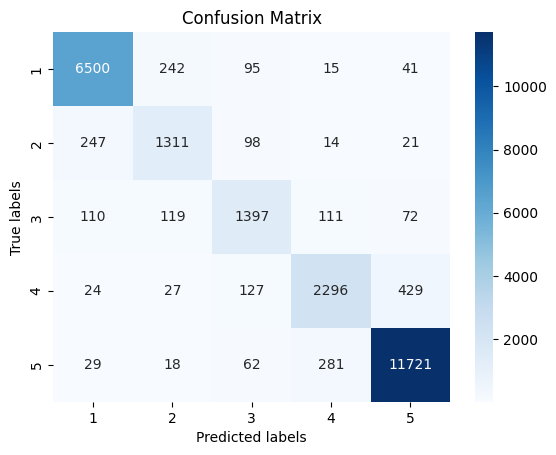

In [ ]:
# Classification Report and Confustion Matrx based on the predictions
print(classification_report(y_actual, y_pred))

ax= plt.subplot()
cm = confusion_matrix(y_actual, y_pred)
sns.heatmap(cm, annot=True, fmt='g', ax=ax, cmap="Blues")
ax.set_xlabel('Predicted labels')
ax.set_ylabel('True labels')
ax.set_title('Confusion Matrix')
ax.xaxis.set_ticklabels(['1', '2', '3', '4', '5'])
ax.yaxis.set_ticklabels(['1', '2', '3', '4', '5'])